In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch

In [2]:
from gluonts.dataset.multivariate_grouper import MultivariateGrouper
from gluonts.dataset.repository.datasets import dataset_recipes, get_dataset
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import MultivariateEvaluator

from gluonts.torch.model.crossformer import CrossformerEstimator

In [3]:
dataset = get_dataset("electricity_nips", regenerate=False)

In [4]:
train_grouper = MultivariateGrouper(
    max_target_dim=int(dataset.metadata.feat_static_cat[0].cardinality)
)

test_grouper = MultivariateGrouper(
    num_test_dates=int(len(dataset.test) / len(dataset.train)),
    max_target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
)

In [5]:
dataset_train = train_grouper(dataset.train)
dataset_test = test_grouper(dataset.test)

/Users/kashif/Github/gluon-ts/src/gluonts/dataset/common.py:263: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.Period(val, freq)


In [8]:
estimator = CrossformerEstimator(
    freq=dataset.metadata.freq,
    prediction_length=dataset.metadata.prediction_length,
    context_length=dataset.metadata.prediction_length * 3,
    scaling="std",
    trainer_kwargs=dict(max_epochs=10, devices="auto"),
)

In [9]:
predictor = estimator.train(
    dataset_train, cache_data=True, shuffle_buffer_length=1024
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kashif/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ CrossformerModel │  864 K │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 864 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 864 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 267                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/kashif/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Epoch 0, global step 50: 'train_loss' reached 5.14139 (best 5.14139), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_733/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 4.75781 (best 4.75781), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_733/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 4.47467 (best 4.47467), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_733/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 4.35001 (best 4.35001), saving model to '/Users/kashif/Github/gluon-ts/examples/lightning_logs/version_733/checkpoints/epoch=3-step=200.ckpt' as top 1
E

In [10]:
evaluator = MultivariateEvaluator(
    quantiles=(np.arange(20) / 20.0)[1:], target_agg_funcs={"sum": np.sum}
)

In [11]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=dataset_test, predictor=predictor, num_samples=100
)
forecasts = list(forecast_it)
targets = list(ts_it)
agg_metric, _ = evaluator(targets, forecasts, num_series=len(dataset_test))

Running evaluation: 7it [00:00, 190.89it/s]
Running evaluation: 7it [00:00, 236.67it/s]
Running evaluation: 7it [00:00, 236.17it/s]
Running evaluation: 7it [00:00, 236.65it/s]
Running evaluation: 7it [00:00, 232.73it/s]
Running evaluation: 7it [00:00, 245.83it/s]
Running evaluation: 7it [00:00, 239.01it/s]
Running evaluation: 7it [00:00, 240.88it/s]
Running evaluation: 7it [00:00, 216.64it/s]
Running evaluation: 7it [00:00, 233.95it/s]
Running evaluation: 7it [00:00, 230.09it/s]
Running evaluation: 7it [00:00, 230.61it/s]
Running evaluation: 7it [00:00, 232.26it/s]
Running evaluation: 7it [00:00, 233.96it/s]
Running evaluation: 7it [00:00, 235.04it/s]
Running evaluation: 7it [00:00, 225.52it/s]
Running evaluation: 7it [00:00, 226.69it/s]
Running evaluation: 7it [00:00, 233.30it/s]
Running evaluation: 7it [00:00, 233.07it/s]
Running evaluation: 7it [00:00, 230.30it/s]
Running evaluation: 7it [00:00, 225.03it/s]
Running evaluation: 7it [00:00, 235.87it/s]
Running evaluation: 7it [00:00, 

In [12]:
print("CRPS: {}".format(agg_metric["mean_wQuantileLoss"]))
print("ND: {}".format(agg_metric["ND"]))
print("NRMSE: {}".format(agg_metric["NRMSE"]))
print("MSE: {}".format(agg_metric["MSE"]))

CRPS: 0.0638155609243557
ND: 0.08318564188769516
NRMSE: 0.6868643483233305
MSE: 270215.12142751575


In [13]:
print("CRPS-Sum: {}".format(agg_metric["m_sum_mean_wQuantileLoss"]))
print("ND-Sum: {}".format(agg_metric["m_sum_ND"]))
print("NRMSE-Sum: {}".format(agg_metric["m_sum_NRMSE"]))
print("MSE-Sum: {}".format(agg_metric["m_sum_MSE"]))

CRPS-Sum: 0.03256130992073261
ND-Sum: 0.0437398606028053
NRMSE-Sum: 0.05431994856392667
MSE-Sum: 231360844.19047618


In [16]:
  def plot(
      target,
      forecast,
      prediction_length,
      prediction_intervals=(50.0, 90.0),
      color="g",
      fname=None,
  ):
      rows = 4
      cols = 4
      fig, axs = plt.subplots(rows, cols, figsize=(24, 24))
      axx = axs.ravel()
      seq_len, target_dim = target.shape

      ps = [50.0] + [
          50.0 + f * c / 2.0 for c in prediction_intervals for f in [-1.0, +1.0]
      ]
      percentiles_sorted = sorted(set(ps))

      def alpha_for_percentile(p):
          return (p / 100.0) ** 0.3

      legend_handles = None
      legend_labels = None

      for dim in range(0, min(rows * cols, target_dim)):
          ax = axx[dim]

          target[-2 * prediction_length :][dim].plot(ax=ax)
          obs_line = ax.lines[-1]

          ps_data = [
              forecast.quantile(p / 100.0)[:, dim] for p in percentiles_sorted
          ]
          i_p50 = len(percentiles_sorted) // 2

          p50_data = ps_data[i_p50]
          pd.Series(data=p50_data, index=forecast.index).plot(
              color=color, ls="-", ax=ax
          )
          median_line = ax.lines[-1]

          interval_handles = []
          interval_labels = []

          for i in range(len(percentiles_sorted) // 2):
              ptile = percentiles_sorted[i]
              alpha = alpha_for_percentile(ptile)
              interval = 100 - ptile * 2

              patch = ax.fill_between(
                  forecast.index,
                  ps_data[i],
                  ps_data[-i - 1],
                  facecolor=color,
                  alpha=alpha,
                  interpolate=True,
              )
              interval_handles.append(patch)
              interval_labels.append(f"{interval:.1f}% prediction interval")

          if legend_handles is None:
              legend_handles = [obs_line, median_line] + interval_handles[::-1]
              legend_labels = (
                  ["observations", "median prediction"]
                  + interval_labels[::-1]
              )

      axx[0].legend(legend_handles, legend_labels, loc="upper left")

      if fname is not None:
          plt.savefig(fname, bbox_inches="tight", pad_inches=0.05)

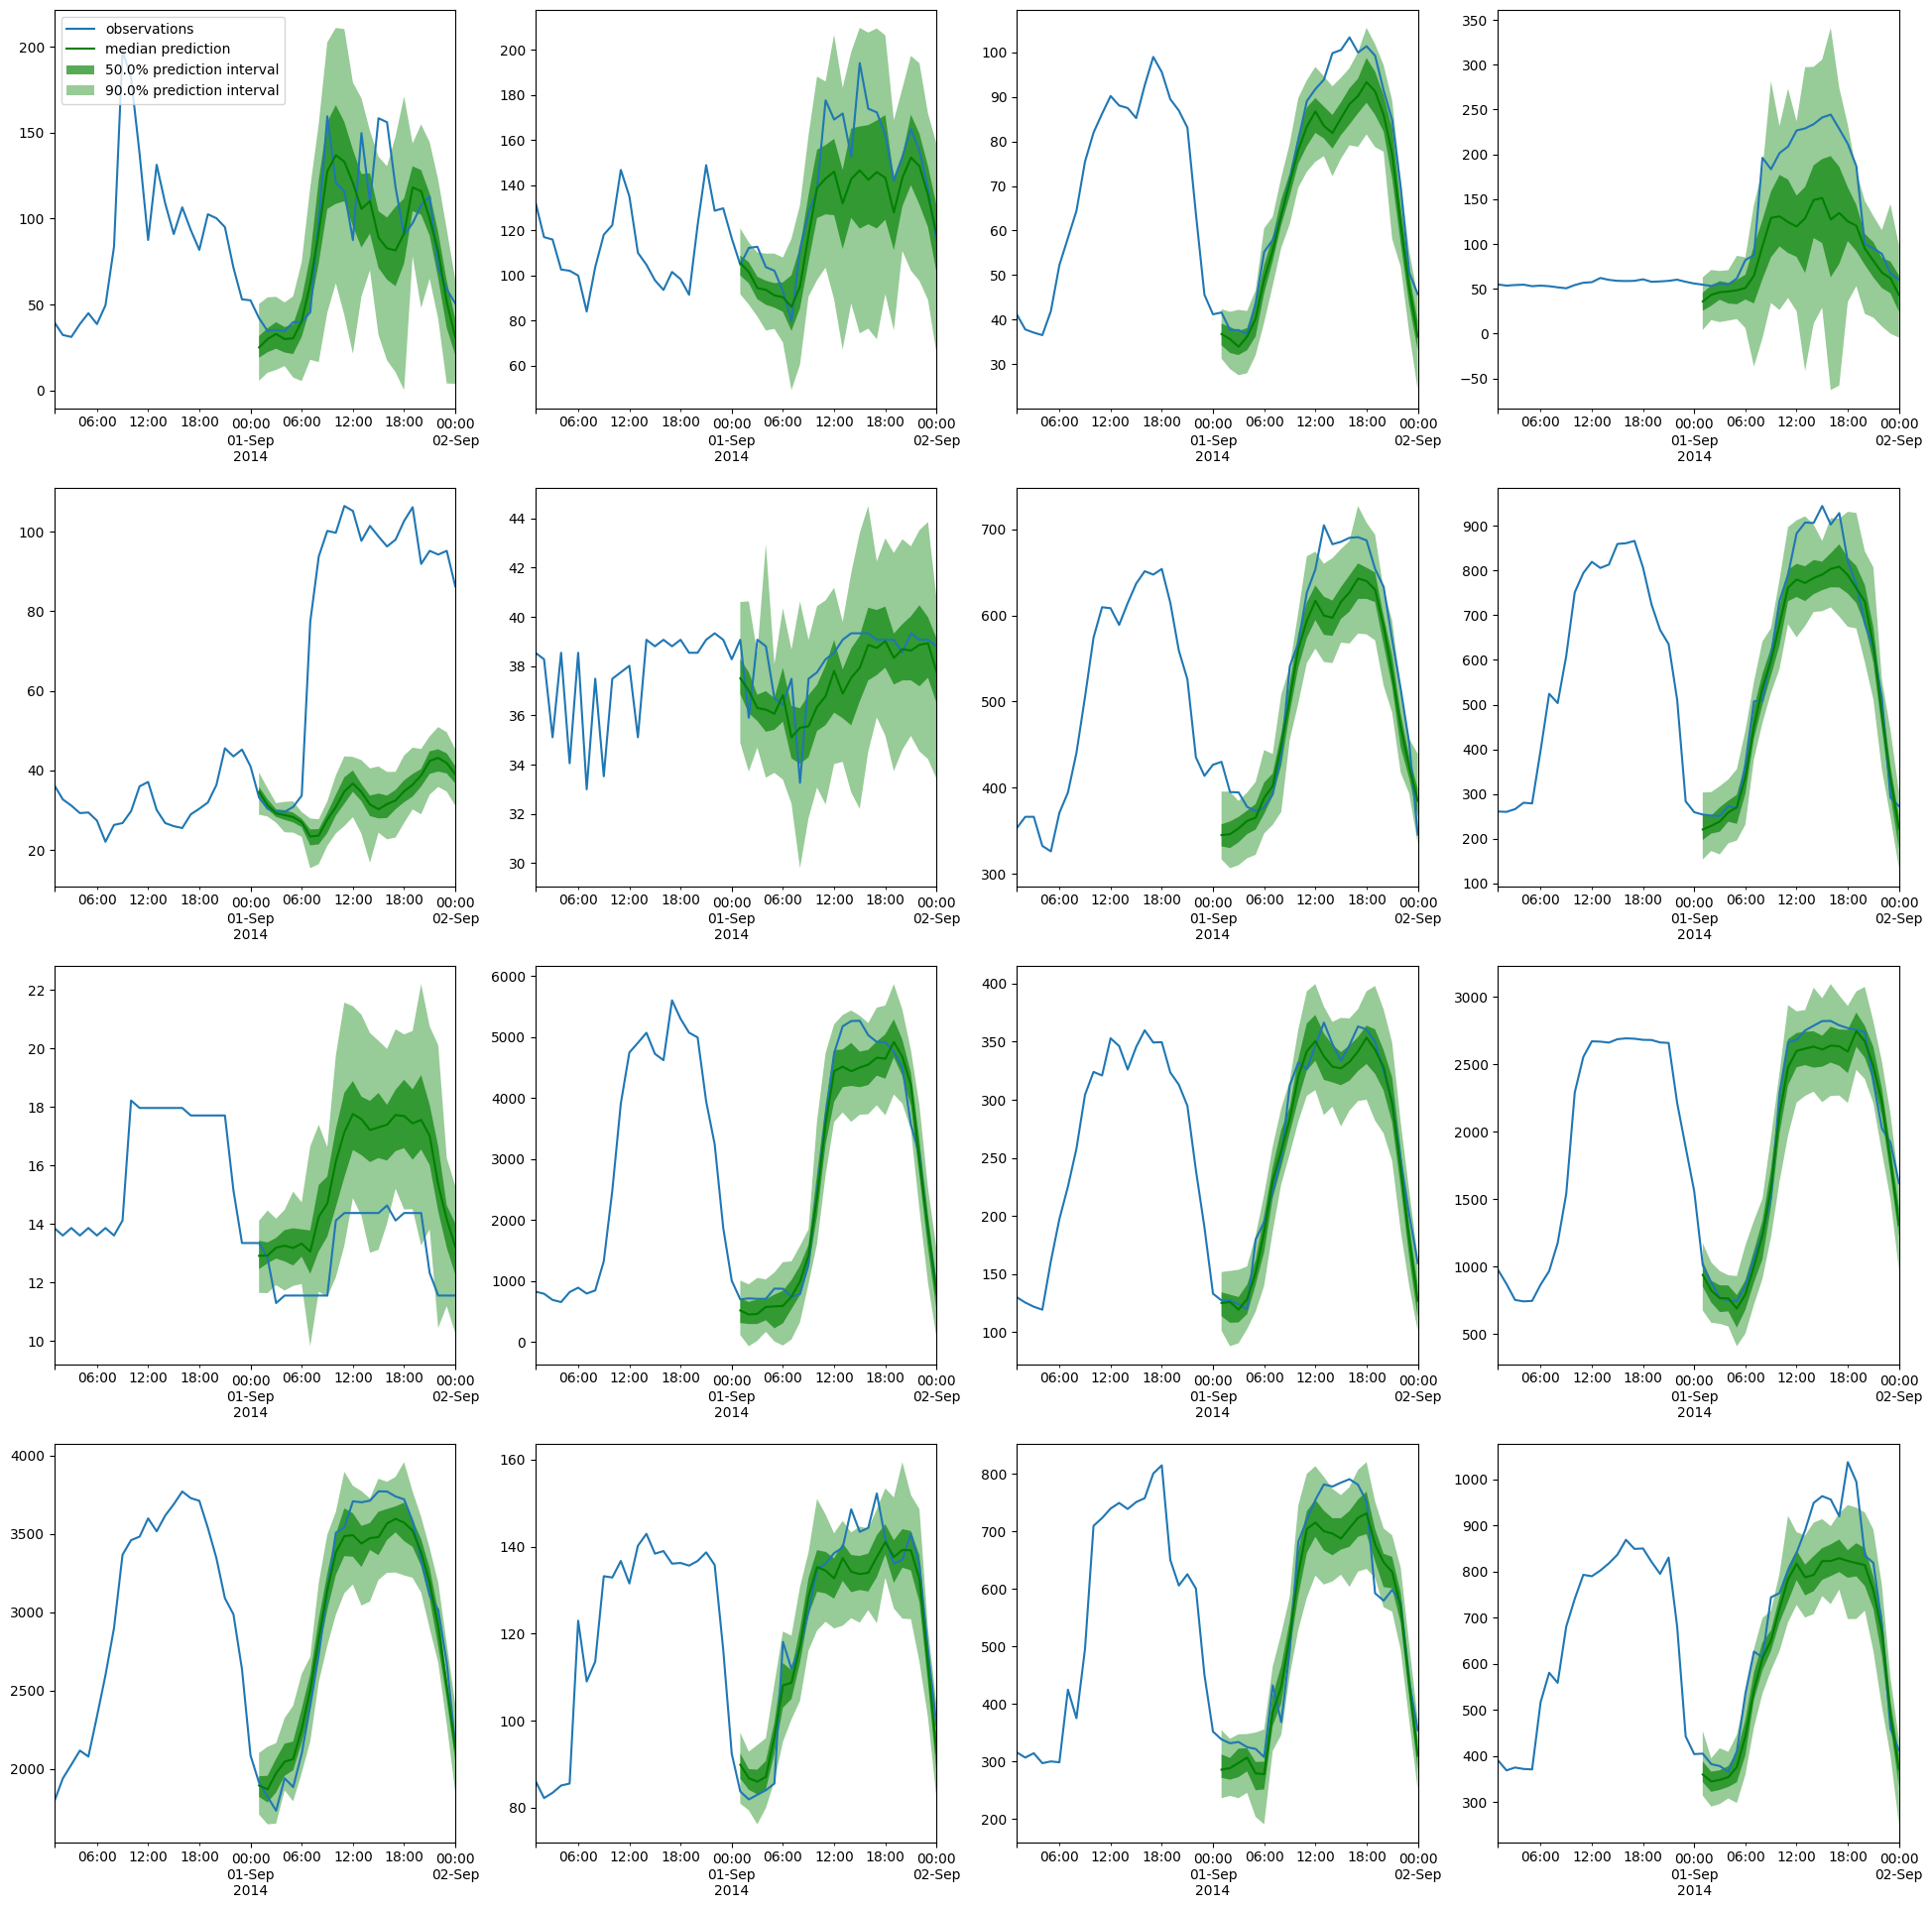

In [17]:
plot(
    target=targets[0],
    forecast=forecasts[0],
    prediction_length=dataset.metadata.prediction_length,
)
plt.show()